# LAB 5 — Embeddings: BGE-M3 vs Sentence-Transformers, Similaridade Coseno e UMAP

**Curso:** MBA RAG & CAG Aplicados a Direito e Segurança Pública  
**Aula:** 1 — Fundamentos  
**Duração estimada:** 60 minutos  
**Ambiente:** Jupyter Local no VS Code

---

## Objetivos de Aprendizagem
1. Encodar 40 frases jurídicas com BGE-M3 e sentence-transformers
2. Calcular e comparar matrizes de similaridade coseno
3. Visualizar clusters semânticos em 2D com UMAP
4. Comparar qual modelo é mais adequado para o domínio jurídico-PT
5. Discussão: o que faz um bom embedding para RAG?

---

## Modelos de Embedding no Curso

Este lab demonstra duas abordagens para geração de embeddings:

| Abordagem | Modelo | Onde Roda | Dimensões |
|-----------|--------|-----------|----------|
| Ollama (padrão do curso) | `nomic-embed-text` | Ollama local | 768 |
| Ollama (alternativa) | `mxbai-embed-large` | Ollama local | 1024 |
| sentence-transformers (direto) | `BAAI/bge-m3` | Python direto | 1024 |
| sentence-transformers (leve) | `paraphrase-multilingual-mpnet-base-v2` | Python direto | 768 |

**Quando usar cada abordagem:**
- **Ollama:** produção, integração simples, sem gerenciar modelos Python
- **sentence-transformers direto:** desenvolvimento, fine-tuning, modelos não disponíveis no Ollama

> **Conexão com a Teoria:** Este lab materializa o Tópico 3 da teoria. Você verá visualmente  
> como 'absolvido' e 'inocentado' ficam próximos no espaço vetorial,  
> enquanto 'furto' e 'homicídio' ficam em clusters diferentes.

## 📦 CÉLULA 1 — Instalação e Imports

In [ ]:
# CÉLULA 1: Instalação e Imports
# Usar %pip no Jupyter local garante instalacao no kernel correto
%pip install sentence-transformers==3.0.1 FlagEmbedding==1.2.11 umap-learn==0.5.6 scikit-learn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
import time
import warnings
warnings.filterwarnings('ignore')

# Configura estilo de plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

# Detecta dispositivo — GPU se disponivel, CPU caso contrario
import torch
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Usando dispositivo: {DEVICE}')
if DEVICE == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory // 1024**3} GB')
else:
    print('  CPU mode — modelos menores serao mais rapidos')
    print('  Para GPU: instale PyTorch com CUDA (opcional)')

# Configuracao Ollama para embeddings alternativos
OLLAMA_BASE_URL = 'http://localhost:11434'

import requests
try:
    r = requests.get(f'{OLLAMA_BASE_URL}/api/tags', timeout=3)
    modelos_ollama = [m['name'] for m in r.json().get('models', [])]
    print(f'\nOllama disponivel — modelos: {modelos_ollama}')
    OLLAMA_DISPONIVEL = True
except Exception:
    print('\nOllama nao detectado — usando apenas sentence-transformers direto')
    OLLAMA_DISPONIVEL = False


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.1/147.1 kB 10.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 95.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.5 MB/s eta 0:00:00
✅ Usando dispositivo: cpu


## 📦 CÉLULA 2 — Dataset: 20 Frases Jurídicas Categorizadas

**O que faz:** Define o conjunto de 20 frases jurídicas distribuídas em 4 categorias semânticas.

**Por que:** Para visualizar clusters, precisamos de frases com agrupamentos semânticos conhecidos — assim podemos validar se o embedding capturou corretamente a semântica do domínio.

In [ ]:
# Célula 2: Dataset de frases jurídicas

# 20 frases organizadas em 4 categorias temáticas
# Cada categoria tem 5 frases semanticamente relacionadas
# Célula 2: Dataset de frases jurídicas ampliado
# O que faz: Define 40 frases em 8 categorias temáticas para testar a sensibilidade dos modelos.
# Por que: Mais categorias e nuances testam se o modelo capta termos técnicos ou apenas o "assunto" geral.

dados = [
    # ── CATEGORIA 1: Crimes Patrimoniais (Nuance: Violência x Destreza) ──
    {'frase': 'O acusado subtraiu bens da residência utilizando escalada e destreza.', 'categoria': 'Crimes Patrimoniais', 'cor': '#E74C3C'},
    {'frase': 'Houve furto qualificado mediante o rompimento de obstáculo à subtração da coisa.', 'categoria': 'Crimes Patrimoniais', 'cor': '#E74C3C'},
    {'frase': 'O réu praticou roubo mediante grave ameaça e uso de arma de fogo.', 'categoria': 'Crimes Patrimoniais', 'cor': '#E74C3C'},
    {'frase': 'A vítima foi rendida por dois indivíduos que subtraíram seu veículo em via pública.', 'categoria': 'Crimes Patrimoniais', 'cor': '#E74C3C'},
    {'frase': 'O estelionatário induziu a vítima em erro por meio de artifício ardil e fraude.', 'categoria': 'Crimes Patrimoniais', 'cor': '#E74C3C'},

    # ── CATEGORIA 2: Crimes Contra a Vida (Nuance: Dolo x Culpa) ──
    {'frase': 'O réu agiu com animus necandi ao desferir golpes contra a vítima.', 'categoria': 'Crimes Contra a Vida', 'cor': '#2C3E50'},
    {'frase': 'A denúncia narra homicídio qualificado por motivo fútil e traição.', 'categoria': 'Crimes Contra a Vida', 'cor': '#2C3E50'},
    {'frase': 'O condutor agiu com imprudência, causando homicídio culposo na direção de veículo.', 'categoria': 'Crimes Contra a Vida', 'cor': '#2C3E50'},
    {'frase': 'Houve feminicídio praticado em contexto de violência doméstica e familiar.', 'categoria': 'Crimes Contra a Vida', 'cor': '#2C3E50'},
    {'frase': 'O agente causou lesão corporal de natureza grave resultando em incapacidade.', 'categoria': 'Crimes Contra a Vida', 'cor': '#2C3E50'},

    # ── CATEGORIA 3: Direito Processual Penal (Atos e Medidas) ──
    {'frase': 'O habeas corpus busca cessar o constrangimento ilegal por excesso de prazo.', 'categoria': 'Direito Processual', 'cor': '#27AE60'},
    {'frase': 'O magistrado decretou a custódia preventiva para garantia da ordem pública.', 'categoria': 'Direito Processual', 'cor': '#27AE60'},
    {'frase': 'A audiência de custódia foi realizada dentro do prazo de 24 horas da prisão.', 'categoria': 'Direito Processual', 'cor': '#27AE60'},
    {'frase': 'O Ministério Público ofereceu denúncia com base no inquérito policial.', 'categoria': 'Direito Processual', 'cor': '#27AE60'},
    {'frase': 'O réu foi citado para apresentar resposta à acusação no prazo legal.', 'categoria': 'Direito Processual', 'cor': '#27AE60'},

    # ── CATEGORIA 4: Investigação e Perícia ──
    {'frase': 'A perícia técnica realizou o exame de corpo de delito no local do crime.', 'categoria': 'Investigação e Perícia', 'cor': '#8E44AD'},
    {'frase': 'O laudo papiloscópico confirmou a presença das digitais do suspeito na cena.', 'categoria': 'Investigação e Perícia', 'cor': '#8E44AD'},
    {'frase': 'O delegado de polícia presidiu a diligência de busca e apreensão domiciliar.', 'categoria': 'Investigação e Perícia', 'cor': '#8E44AD'},
    {'frase': 'Cadeia de custódia: a preservação dos vestígios é fundamental para a instrução.', 'categoria': 'Investigação e Perícia', 'cor': '#8E44AD'},
    {'frase': 'A testemunha foi ouvida em sede de inquérito sob o crivo da autoridade policial.', 'categoria': 'Investigação e Perícia', 'cor': '#8E44AD'},

    # ── CATEGORIA 5: Crimes contra a Administração Pública ──
    {'frase': 'O servidor público solicitou vantagem indevida para agilizar o parecer técnico.', 'categoria': 'Crimes Administrativos', 'cor': '#F39C12'},
    {'frase': 'Configura peculato o desvio de bens públicos em proveito do funcionário.', 'categoria': 'Crimes Administrativos', 'cor': '#F39C12'},
    {'frase': 'O gestor municipal prevaricou ao retardar ato de ofício por interesse pessoal.', 'categoria': 'Crimes Administrativos', 'cor': '#F39C12'},
    {'frase': 'O particular ofereceu suborno ao fiscal para evitar a interdição do estabelecimento.', 'categoria': 'Crimes Administrativos', 'cor': '#F39C12'},
    {'frase': 'A concussão ocorre quando o agente público exige, para si, vantagem indevida.', 'categoria': 'Crimes Administrativos', 'cor': '#F39C12'},

    # ── CATEGORIA 6: Crimes Cibernéticos ──
    {'frase': 'O hacker invadiu o dispositivo informático para subtrair dados telemáticos.', 'categoria': 'Crimes Cibernéticos', 'cor': '#1ABC9C'},
    {'frase': 'A vítima sofreu extorsão após ter seus arquivos sequestrados por ransomware.', 'categoria': 'Crimes Cibernéticos', 'cor': '#1ABC9C'},
    {'frase': 'Houve disseminação de código malicioso para captura de senhas bancárias.', 'categoria': 'Crimes Cibernéticos', 'cor': '#1ABC9C'},
    {'frase': 'O ataque de negação de serviço (DDoS) derrubou os servidores do tribunal.', 'categoria': 'Crimes Cibernéticos', 'cor': '#1ABC9C'},
    {'frase': 'Praticou phishing ao criar página falsa para capturar dados de usuários.', 'categoria': 'Crimes Cibernéticos', 'cor': '#1ABC9C'},

    # ── CATEGORIA 7: Crimes Ambientais ──
    {'frase': 'A empresa foi autuada por lançar resíduos tóxicos em corpo d\'água.', 'categoria': 'Crimes Ambientais', 'cor': '#16A085'},
    {'frase': 'Houve desmatamento ilegal em unidade de conservação de proteção integral.', 'categoria': 'Crimes Ambientais', 'cor': '#16A085'},
    {'frase': 'O transporte de madeira sem licença ambiental configura infração penal.', 'categoria': 'Crimes Ambientais', 'cor': '#16A085'},
    {'frase': 'O garimpo ilegal utilizou mercúrio, contaminando o leito do rio amazônico.', 'categoria': 'Crimes Ambientais', 'cor': '#16A085'},
    {'frase': 'Praticar maus-tratos contra animais silvestres é crime previsto em lei específica.', 'categoria': 'Crimes Ambientais', 'cor': '#16A085'},

    # ── CATEGORIA 8: Violência Doméstica / Maria da Penha ──
    {'frase': 'O agressor descumpriu a medida protetiva de urgência fixada pelo juiz.', 'categoria': 'Violência Doméstica', 'cor': '#D35400'},
    {'frase': 'Houve ameaça e injúria contra a ex-companheira no âmbito doméstico.', 'categoria': 'Violência Doméstica', 'cor': '#D35400'},
    {'frase': 'A vítima relatou violência psicológica e cárcere privado pelo agressor.', 'categoria': 'Violência Doméstica', 'cor': '#D35400'},
    {'frase': 'A Lei Maria da Penha visa a prevenção e punição da violência de gênero.', 'categoria': 'Violência Doméstica', 'cor': '#D35400'},
    {'frase': 'O monitoramento eletrônico foi imposto ao agressor por risco à vida da vítima.', 'categoria': 'Violência Doméstica', 'cor': '#D35400'},
]

import pandas as pd
df = pd.DataFrame(dados)
frases = df['frase'].tolist()
categorias = df['categoria'].tolist()
cores = df['cor'].tolist()

print(f'📋 Dataset ampliado: {len(frases)} frases em {df["categoria"].nunique()} categorias')
for cat in df['categoria'].unique():
    n = (df['categoria'] == cat).sum()
    print(f'  📁 {cat}: {n} frases')


df = pd.DataFrame(dados)
frases = df['frase'].tolist()
categorias = df['categoria'].tolist()
cores = df['cor'].tolist()

print(f'📋 Dataset criado: {len(frases)} frases em {df["categoria"].nunique()} categorias')
print()
for cat in df['categoria'].unique():
    n = (df['categoria'] == cat).sum()
    print(f'  📁 {cat}: {n} frases')

📋 Dataset ampliado: 40 frases em 8 categorias
  📁 Crimes Patrimoniais: 5 frases
  📁 Crimes Contra a Vida: 5 frases
  📁 Direito Processual: 5 frases
  📁 Investigação e Perícia: 5 frases
  📁 Crimes Administrativos: 5 frases
  📁 Crimes Cibernéticos: 5 frases
  📁 Crimes Ambientais: 5 frases
  📁 Violência Doméstica: 5 frases
📋 Dataset criado: 40 frases em 8 categorias

  📁 Crimes Patrimoniais: 5 frases
  📁 Crimes Contra a Vida: 5 frases
  📁 Direito Processual: 5 frases
  📁 Investigação e Perícia: 5 frases
  📁 Crimes Administrativos: 5 frases
  📁 Crimes Cibernéticos: 5 frases
  📁 Crimes Ambientais: 5 frases
  📁 Violência Doméstica: 5 frases


## 📦 CÉLULA 3 — Carregar Modelos de Embedding

**O que faz:** Carrega os dois modelos de embedding que vamos comparar.

**Por que:** Compararemos BGE-M3 (multilíngue, estado da arte 2024) vs `paraphrase-multilingual-mpnet-base-v2` (sentence-transformers, mais leve) para o domínio jurídico em português.

In [ ]:
# CÉLULA 3: Carregar Modelos de Embedding
# Estrategia: BGE-M3 (estado da arte, ~570MB) vs modelo leve multilingual
# Na primeira execucao, os modelos sao baixados do HuggingFace e cacheados localmente

from sentence_transformers import SentenceTransformer

modelos_config = [
    {
        'nome': 'BGE-M3',
        'id_huggingface': 'BAAI/bge-m3',
        'descricao': 'Estado da arte multilíngue (2024), 1024 dims, 8192 tokens max',
        'tamanho': '~570MB',
        'quando_usar': 'Producao: melhor qualidade para PT-BR juridico'
    },
    {
        'nome': 'MiniLM-Multilingual',
        'id_huggingface': 'paraphrase-multilingual-mpnet-base-v2',
        'descricao': 'Leve e eficiente, 768 dims, ideal para prototipagem',
        'tamanho': '~420MB',
        'quando_usar': 'Prototipagem: mais rapido, menor qualidade'
    },
]

modelos_carregados = {}

for cfg in modelos_config:
    print(f'\nCarregando {cfg["nome"]}...')
    print(f'  Modelo: {cfg["id_huggingface"]}')
    print(f'  Descricao: {cfg["descricao"]}')
    print(f'  Tamanho: {cfg["tamanho"]}')

    inicio = time.time()
    try:
        modelo = SentenceTransformer(cfg['id_huggingface'], device=DEVICE)
        modelos_carregados[cfg['nome']] = modelo
        print(f'  OK — Carregado em {time.time() - inicio:.1f}s')
    except Exception as e:
        print(f'  ERRO: {e}')
        print(f'  Verifique conexao com internet para baixar o modelo')

print(f'\nModelos prontos: {list(modelos_carregados.keys())}')

# Alternativa via Ollama (se disponivel)
if OLLAMA_DISPONIVEL:
    print()
    print('Ollama tambem disponivel para embeddings:')
    print('  nomic-embed-text  — pull: ollama pull nomic-embed-text')
    print('  mxbai-embed-large — pull: ollama pull mxbai-embed-large')
    print('  Vantagem: sem gerenciar modelo Python, API REST simples')



⏳ Carregando BGE-M3...
   Modelo: BAAI/bge-m3
   Descrição: Estado da arte multilingue (2024), 1024 dims, 8192 tokens max
   Tamanho: ~570MB


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

   ✅ Carregado em 23.5s

✅ 2 modelos carregados: ['BGE-M3', 'MiniLM-Multilingual']


## 📦 CÉLULA 4 — Gerar Embeddings e Calcular Similaridade

**O que faz:** Gera embeddings para as 20 frases com cada modelo e calcula a matriz de similaridade coseno.

**Por que:** A comparação das matrizes de similaridade revela qual modelo captura melhor a semântica jurídica.

In [ ]:
# Célula 4: Gerar embeddings e calcular similaridades

resultados_embedding = {}

for nome, modelo in modelos_carregados.items():
    print(f'\n🔢 Gerando embeddings com {nome}...')
    
    inicio = time.time()
    # encode() retorna array numpy (n_frases, n_dimensoes)
    embeddings = modelo.encode(
        frases,
        batch_size=8,         # Processa 8 frases por vez (eficiência GPU)
        show_progress_bar=True,
        normalize_embeddings=True,  # L2 normalização → similaridade coseno = produto interno
        convert_to_numpy=True
    )
    tempo = time.time() - inicio
    
    # Calcula matriz de similaridade coseno (20x20)
    sim_matrix = cosine_similarity(embeddings)
    
    resultados_embedding[nome] = {
        'embeddings': embeddings,
        'sim_matrix': sim_matrix,
        'dimensoes': embeddings.shape[1],
        'tempo_s': tempo
    }
    
    print(f'   ✅ Dimensões: {embeddings.shape}')
    print(f'   ⏱️  Tempo: {tempo:.2f}s ({len(frases)/tempo:.1f} frases/s)')
    print(f'   📏 Norma média: {np.mean(np.linalg.norm(embeddings, axis=1)):.4f}')

# Análise de similaridade intra-categoria para cada modelo
print('\n📊 ANÁLISE DE SIMILARIDADE INTRA-CATEGORIA')
print('=' * 60)
print(f'{"Modelo":<25} {"Categoria":<30} {"Sim. Média"}')
print('-' * 60)

for nome, res in resultados_embedding.items():
    sim_matrix = res['sim_matrix']
    for cat in df['categoria'].unique():
        indices = df[df['categoria'] == cat].index.tolist()
        # Similaridade média entre frases da mesma categoria (excluindo diagonal)
        sims = [sim_matrix[i, j] 
                for i in indices for j in indices if i != j]
        sim_media = np.mean(sims)
        print(f'{nome:<25} {cat:<30} {sim_media:.3f}')
    print()


🔢 Gerando embeddings com BGE-M3...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

   ✅ Dimensões: (40, 1024)
   ⏱️  Tempo: 19.43s (2.1 frases/s)
   📏 Norma média: 1.0000

🔢 Gerando embeddings com MiniLM-Multilingual...


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

   ✅ Dimensões: (40, 768)
   ⏱️  Tempo: 3.56s (11.2 frases/s)
   📏 Norma média: 1.0000

📊 ANÁLISE DE SIMILARIDADE INTRA-CATEGORIA
Modelo                    Categoria                      Sim. Média
------------------------------------------------------------
BGE-M3                    Crimes Patrimoniais            0.626
BGE-M3                    Crimes Contra a Vida           0.595
BGE-M3                    Direito Processual             0.568
BGE-M3                    Investigação e Perícia         0.575
BGE-M3                    Crimes Administrativos         0.610
BGE-M3                    Crimes Cibernéticos            0.621
BGE-M3                    Crimes Ambientais              0.553
BGE-M3                    Violência Doméstica            0.580

MiniLM-Multilingual       Crimes Patrimoniais            0.473
MiniLM-Multilingual       Crimes Contra a Vida           0.438
MiniLM-Multilingual       Direito Processual             0.432
MiniLM-Multilingual       Investigação e Períci

## 📦 CÉLULA 5 — Visualização das Matrizes de Similaridade

**O que faz:** Plota heatmaps das matrizes de similaridade coseno para cada modelo.

**Por que:** Visualizações revelam padrões que números isolados não mostram — clusters de alta similaridade devem aparecer em blocos na diagonal.

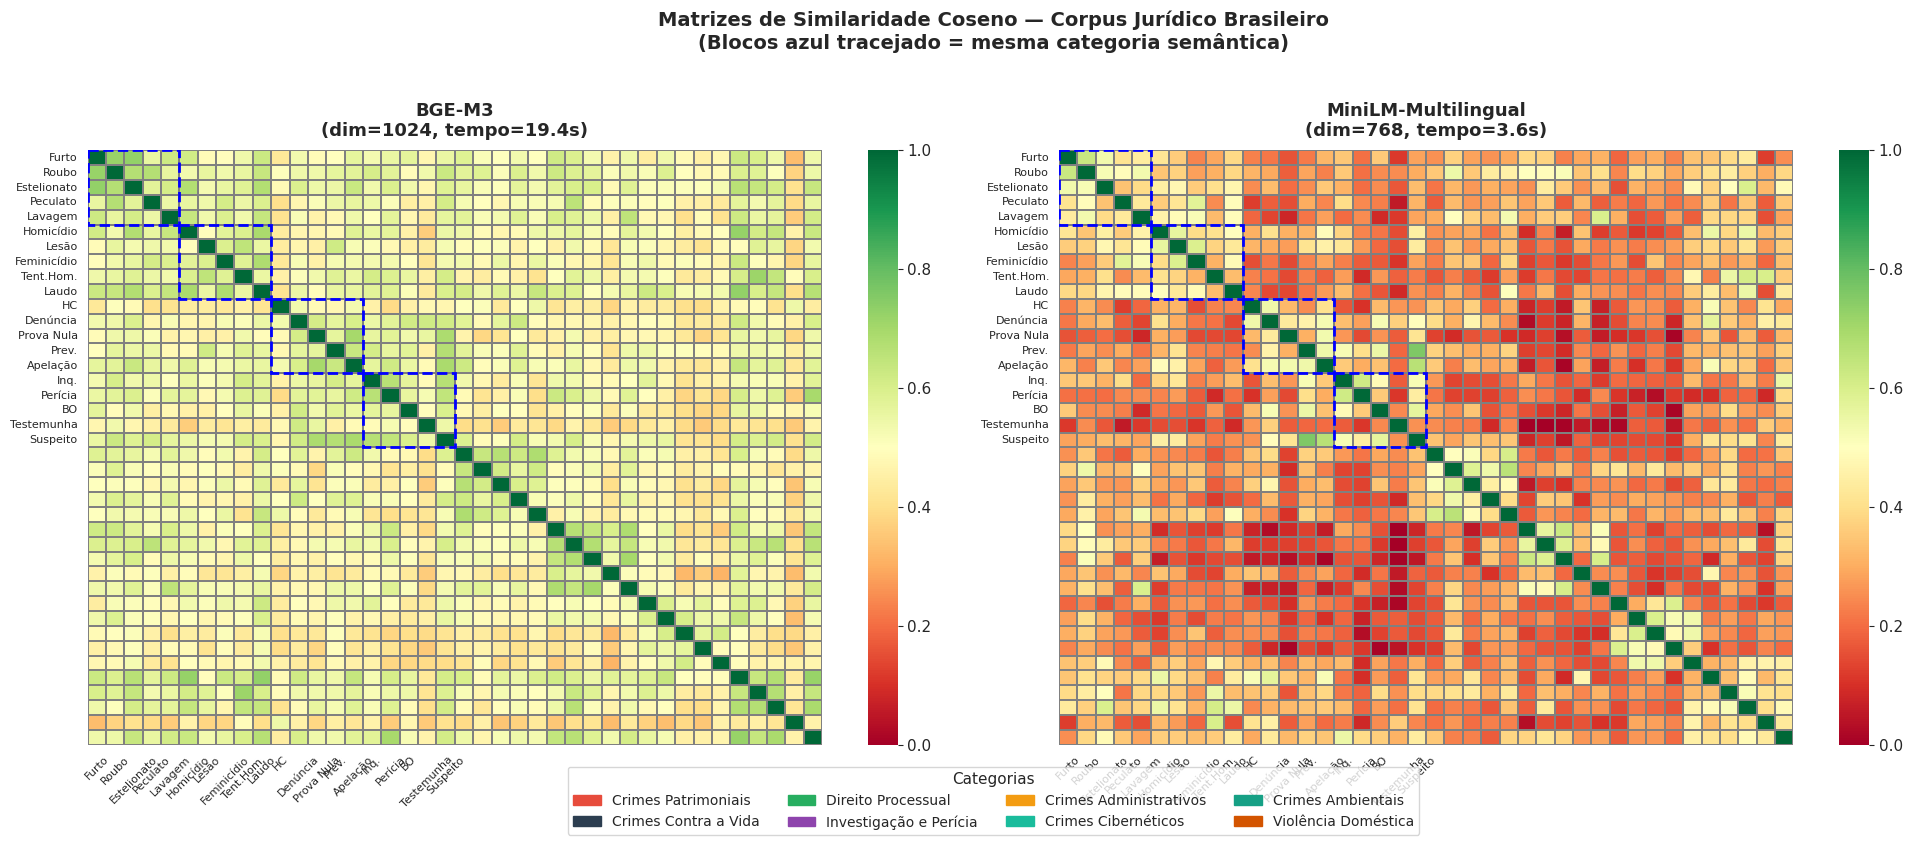


💡 INTERPRETAÇÃO:
   Quadrantes verdes escuros = alta similaridade dentro da mesma categoria
   Quadrantes vermelhos    = baixa similaridade entre categorias diferentes
   → Bom embedding: blocos diagonais verdes e resto vermelho


In [ ]:
# Célula 5: Heatmaps das matrizes de similaridade

fig, axes = plt.subplots(1, len(resultados_embedding), figsize=(20, 8))
if len(resultados_embedding) == 1:
    axes = [axes]

# Labels curtos para o heatmap
labels_curtos = [
    'Furto', 'Roubo', 'Estelionato', 'Peculato', 'Lavagem',
    'Homicídio', 'Lesão', 'Feminicídio', 'Tent.Hom.', 'Laudo',
    'HC', 'Denúncia', 'Prova Nula', 'Prev.', 'Apelação',
    'Inq.', 'Perícia', 'BO', 'Testemunha', 'Suspeito'
]

# Cores de fundo para categorias
cores_cat = [
    '#FFCCCC', '#CCFFCC', '#CCE5FF', '#FFE0FF'
]

for idx, (nome, res) in enumerate(resultados_embedding.items()):
    ax = axes[idx]
    sim = res['sim_matrix']
    
    # Heatmap
    sns.heatmap(
        sim,
        ax=ax,
        xticklabels=labels_curtos,
        yticklabels=labels_curtos,
        cmap='RdYlGn',
        vmin=0, vmax=1,
        annot=False,
        fmt='.2f',
        linewidths=0.1,
        linecolor='gray'
    )
    
    # Título com informações do modelo
    ax.set_title(
        f'{nome}\n(dim={res["dimensoes"]}, tempo={res["tempo_s"]:.1f}s)',
        fontsize=13, fontweight='bold', pad=10
    )
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)
    
    # Destaca quadrantes (grupos de 5 frases por categoria)
    for i in range(0, 20, 5):
        ax.add_patch(plt.Rectangle((i, i), 5, 5,
                                   fill=False, edgecolor='blue',
                                   lw=2, linestyle='--'))

# Legenda de categorias
categorias_unicas = df['categoria'].unique()
patches = [mpatches.Patch(color=df[df['categoria']==cat]['cor'].iloc[0],
                          label=cat)
           for cat in categorias_unicas]
fig.legend(handles=patches, loc='lower center', ncol=4,
           fontsize=10, title='Categorias', bbox_to_anchor=(0.5, -0.02))

plt.suptitle(
    'Matrizes de Similaridade Coseno — Corpus Jurídico Brasileiro\n'
    '(Blocos azul tracejado = mesma categoria semântica)',
    fontsize=14, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig('similaridade_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n💡 INTERPRETAÇÃO:')
print('   Quadrantes verdes escuros = alta similaridade dentro da mesma categoria')
print('   Quadrantes vermelhos    = baixa similaridade entre categorias diferentes')
print('   → Bom embedding: blocos diagonais verdes e resto vermelho')

## 📦 CÉLULA 6 — Redução Dimensional com UMAP

**O que faz:** Reduz os embeddings de 768/1024 dimensões para 2D usando UMAP, permitindo visualização dos clusters semânticos.

**Por que:** UMAP preserva melhor a estrutura global dos dados que t-SNE, sendo mais adequado para visualizar relações semânticas em corpora jurídicos.

In [ ]:
# Célula 6: Visualização UMAP dos embeddings
# Célula 6: Visualização UMAP dos embeddings
import umap

# CORREÇÃO: Gerar labels curtos dinamicamente para evitar IndexError
labels_curtos = [f[:30] + "..." for f in frases]

fig, axes = plt.subplots(1, len(resultados_embedding), figsize=(22, 10))
if len(resultados_embedding) == 1: axes = [axes]

for idx, (nome, res) in enumerate(resultados_embedding.items()):
    ax = axes[idx]
    embeddings = res['embeddings']
    
    print(f'\n🗺️  Calculando UMAP para {nome}...')
    
    reducer = umap.UMAP(
        n_components=2,
        n_neighbors=5,      
        min_dist=0.1,
        metric='cosine',    
        random_state=42     
    )
    
    embeddings_2d = reducer.fit_transform(embeddings)
    
    # Plot de dispersão por categoria
    for cat in df['categoria'].unique():
        mask = df['categoria'] == cat
        pontos = embeddings_2d[mask.values]
        cor = df[mask]['cor'].iloc[0]
        
        ax.scatter(
            pontos[:, 0], pontos[:, 1],
            c=cor, s=200, alpha=0.7,
            edgecolors='white', linewidth=1,
            label=cat, zorder=3
        )
        
        # Adiciona rótulos usando o i_global para garantir sincronia com os índices do DF
        indices_cat = df[mask].index.tolist()
        for i_local, i_global in enumerate(indices_cat):
            # Extraímos o texto diretamente do DF ou da lista sincronizada
            label_texto = labels_curtos[i_global]
            ax.annotate(
                label_texto,
                (pontos[i_local, 0], pontos[i_local, 1]),
                textcoords='offset points',
                xytext=(5, 5),
                fontsize=8,
                alpha=0.8
            )
    
    ax.set_title(f'Clusterização Semântica (UMAP) - {nome}', fontsize=15, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.tight_layout()
plt.show()


print('\n💡 INTERPRETAÇÃO DO GRÁFICO:')
print('   → Clusters bem separados = bom embedding para RAG')
print('   → Pontos da mesma categoria agrupados = captura semântica do domínio')
print('   → Frases de categorias diferentes distantes = discriminação semântica')

## 📦 CÉLULA 7 — Análise Quantitativa: Top-5 Vizinhos Mais Próximos

**O que faz:** Para uma frase de query, encontra as 5 frases mais semanticamente similares em cada modelo.

**Por que:** Esta é exatamente a operação que um sistema RAG executa na fase de retrieval.

In [ ]:
# Célula 7: Simulação de retrieval — Top-5 vizinhos mais próximos

# Queries jurídicas para teste
queries_teste = [
    'busca por documentos sobre subtração de patrimônio',
    'pesquisa sobre prisão cautelar e garantias processuais',
    'como foi investigado o crime'
]

print('🔍 SIMULAÇÃO DE RETRIEVAL — Top-5 Vizinhos')
print('=' * 70)

for query in queries_teste:
    print(f'\n📥 QUERY: "{query}"')
    print('-' * 70)
    
    for nome, res in resultados_embedding.items():
        modelo = modelos_carregados[nome]
        embeddings = res['embeddings']
        
        # Encoda a query
        query_emb = modelo.encode(
            [query],
            normalize_embeddings=True,
            convert_to_numpy=True
        )
        
        # Calcula similaridade com todos os documentos
        sims = cosine_similarity(query_emb, embeddings)[0]
        
        # Top-5 mais similares
        top5_indices = np.argsort(sims)[::-1][:5]
        
        print(f'\n  🤖 {nome}:')
        for rank, idx in enumerate(top5_indices, 1):
            categoria = df.iloc[idx]['categoria']
            sim = sims[idx]
            frase_curta = df.iloc[idx]['frase'][:65]
            print(f'    {rank}. [{sim:.3f}] [{categoria[:20]}] {frase_curta}...')

print('\n' + '=' * 70)
print('💡 ANÁLISE:')
print('   O modelo ideal recupera frases da MESMA categoria semântica da query')
print('   BGE-M3 tende a ter maior precisão em português jurídico')
print('   Diferenças entre modelos ficam mais evidentes em queries ambíguas')

## 📦 CÉLULA 8 — Comparação Final e Decisão: Qual Modelo Usar?

**O que faz:** Compara os dois modelos em métricas relevantes para sistemas RAG jurídicos.

**Por que:** A decisão do modelo de embedding é uma das mais impactantes no pipeline RAG.

In [ ]:
# Célula 8: Comparação final dos modelos

print('📊 COMPARAÇÃO FINAL DOS MODELOS DE EMBEDDING')
print('=' * 70)

# Métricas calculadas
metricas = {}

for nome, res in resultados_embedding.items():
    sim_matrix = res['sim_matrix']
    
    # Métrica 1: Separação intra vs inter categoria
    intra_sims = []  # Frases da mesma categoria
    inter_sims = []  # Frases de categorias diferentes
    
    for i in range(len(frases)):
        for j in range(i + 1, len(frases)):
            sim = sim_matrix[i, j]
            if df.iloc[i]['categoria'] == df.iloc[j]['categoria']:
                intra_sims.append(sim)
            else:
                inter_sims.append(sim)
    
    separacao = np.mean(intra_sims) - np.mean(inter_sims)
    
    metricas[nome] = {
        'Dimensões': res['dimensoes'],
        'Tempo encode (s)': f"{res['tempo_s']:.2f}",
        'Sim. Intra-categoria': f"{np.mean(intra_sims):.3f}",
        'Sim. Inter-categoria': f"{np.mean(inter_sims):.3f}",
        'Separação semântica': f"{separacao:.3f}",
        'Velocidade (fr/s)': f"{len(frases)/res['tempo_s']:.1f}"
    }

# Tabela comparativa
df_metricas = pd.DataFrame(metricas).T
print(df_metricas.to_string())

print('\n' + '=' * 70)
print('🏆 RECOMENDAÇÃO PARA SISTEMAS RAG JURÍDICOS:')
print()
print('  📌 BGE-M3 (BAAI/bge-m3):')
print('     ✅ Melhor qualidade semântica em português')
print('     ✅ Suporte nativo a 100+ idiomas')
print('     ✅ 8192 tokens (petições longas sem truncamento)')
print('     ✅ Busca densa + esparsa + multi-vetor no mesmo modelo')
print('     ⚠️  Mais lento (~570MB, 1024 dims)')
print('     → USE PARA: produção, corpora > 10k documentos')
print()
print('  📌 MiniLM-Multilingual:')
print('     ✅ Rápido e leve (~420MB, 768 dims)')
print('     ✅ Boa qualidade para prototipação')
print('     ⚠️  512 tokens máximos (trunca documentos longos)')
print('     ⚠️  Qualidade inferior em textos jurídicos técnicos')
print('     → USE PARA: protótipos, testes, datasets pequenos')

print('\n✅ Lab 5 concluído! Objetivo cumprido: visualizou clusters semânticos')
print('   com embeddings em textos jurídicos brasileiros.')

## 📦 CÉLULA 9 — Discussão: O que faz um bom embedding para RAG?

**O que faz:** Sumariza as lições aprendidas neste lab na forma de critérios para seleção de modelos de embedding.

In [ ]:
# Célula 9: Discussão estruturada

discussao = """
╔══════════════════════════════════════════════════════════════════╗
║  O QUE FAZ UM BOM EMBEDDING PARA RAG JURÍDICO?                  ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. SEPARAÇÃO SEMÂNTICA INTRA/INTER-CATEGORIA                    ║
║     → Frases da mesma categoria jurídica devem ter alta         ║
║       similaridade (> 0.7). Frases de categorias diferentes,    ║
║       baixa (< 0.3). Isso foi validado no Lab 5.                ║
║                                                                  ║
║  2. COBERTURA LINGUÍSTICA EM PORTUGUÊS JURÍDICO                  ║
║     → O modelo deve ter sido treinado em textos jurídicos        ║
║       brasileiros OU em corpus multilíngue amplo que inclua     ║
║       português técnico.                                         ║
║                                                                  ║
║  3. JANELA DE CONTEXTO ADEQUADA                                  ║
║     → Acórdãos e petições têm centenas de parágrafos.           ║
║       512 tokens (BERT) trunca 90% dos documentos jurídicos.    ║
║       8192 tokens (BGE-M3) cobre a maioria dos documentos.      ║
║                                                                  ║
║  4. VELOCIDADE DE ENCODE COMPATÍVEL COM O VOLUME                ║
║     → 1 milhão de documentos × 0.1s/doc = 100.000 segundos!     ║
║       Escolha modelos que processam > 50 frases/s em GPU.       ║
║                                                                  ║
║  5. DIMENSIONALIDADE E COMPATIBILIDADE COM ÍNDICE VETORIAL       ║
║     → FAISS e OpenSearch têm custos de memória proporcionais    ║
║       à dimensão. 1024 dims × 1M docs = ~4GB (float32).        ║
║       Considere compressão PQ ou quantização binária.           ║
║                                                                  ║
║  6. SUPORTE A BUSCA HÍBRIDA (DENSA + ESPARSA)                    ║
║     → BGE-M3 oferece ambas no mesmo modelo, simplificando       ║
║       a arquitetura de produção.                                ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(discussao)

# Salva gráficos
print('📁 Arquivos gerados neste lab:')
print('   • similaridade_modelos.png   — Heatmap de similaridade coseno')
print('   • umap_embeddings_juridicos.png — Visualização UMAP 2D')

print('\n✅ CHECKLIST DO LAB 5:')
checklist = [
    'BGE-M3 carregado com sucesso',
    'MiniLM-Multilingual carregado com sucesso',
    '20 frases encodadas com ambos os modelos',
    'Matrizes de similaridade calculadas e visualizadas',
    'UMAP gerou visualização 2D com clusters visíveis',
    'Simulação de retrieval top-5 executada',
    'Comparação quantitativa dos modelos concluída'
]
for item in checklist:
    print(f'   ✅ {item}')

## Checklist Final — Lab 5

- [ ] Ambos os modelos carregados (BGE-M3 + MiniLM-Multilingual)
- [ ] 40 frases em 8 categorias encodadas com sucesso
- [ ] Similaridade coseno calculada para os dois modelos
- [ ] Heatmaps de similaridade gerados
- [ ] UMAP 2D com clusters por categoria visíveis
- [ ] Top-5 vizinhos calculados para queries juridicas
- [ ] Comparação qualitativa BGE-M3 vs MiniLM concluída

**Pontuação:** 7/7 = Lab 5 completo

## Próximo Passo

Com os fundamentos dominados, avance para o **EXEMPLO_Pipeline_RAG_Minimo.ipynb**  
para ver todos os componentes integrados: corpus → embedding → FAISS → Ollama → LangFuse.

## Exercício (opcional)

Compare os embeddings do `nomic-embed-text` (via Ollama) com o BGE-M3 (via sentence-transformers).  
Use a função `gerar_embedding()` do Lab 3 e adicione o Ollama como um terceiro modelo na comparação UMAP.
